In [1]:
from IPython.display import display, HTML 
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

## 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 가져옴

In [14]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 데이터 셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt # 학습과정 loss와 acc 시각화
# quiz에서는 scale조정, train_test_split 등을 추가

In [2]:
import numpy as np
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [6]:
import matplotlib.pylab as plt
print('타겟 : ', data[0,0])
# print('이미지(28x28을 1차원으로) :', data[0,1:].reshape[28,28])

for row in data[0, 1:].reshape(28,28):
    for pixel in row:
        print('{:3.0f}'.format(pixel), end='')
    print()

타겟 :  5.0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0 

plt.figure(figsize=(1,1))
plt.imshow(data[1,1:].reshape(28,28), cmap='gray)

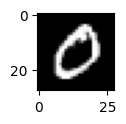

In [8]:
plt.figure(figsize=(1,1))
plt.imshow(data[1, 1:].reshape(28,28), cmap='gray')

In [11]:
pip install opencv-contrib-python

   ---------------------------------------- 0.0/46.2 MB ? eta -:--:--
   -- ------------------------------------- 2.4/46.2 MB 11.2 MB/s eta 0:00:04
   ---- ----------------------------------- 4.7/46.2 MB 11.0 MB/s eta 0:00:04
   ---- ----------------------------------- 5.2/46.2 MB 11.0 MB/s eta 0:00:04
   ----- ---------------------------------- 6.3/46.2 MB 7.1 MB/s eta 0:00:06
   ------- -------------------------------- 8.7/46.2 MB 8.1 MB/s eta 0:00:05
   --------- ------------------------------ 11.0/46.2 MB 8.6 MB/s eta 0:00:05
   ----------- ---------------------------- 13.4/46.2 MB 9.0 MB/s eta 0:00:04
   ------------- -------------------------- 15.7/46.2 MB 9.3 MB/s eta 0:00:04
   --------------- ------------------------ 18.1/46.2 MB 9.5 MB/s eta 0:00:03
   ----------------- ---------------------- 20.4/46.2 MB 9.7 MB/s eta 0:00:03
   ------------------- -------------------- 22.8/46.2 MB 9.8 MB/s eta 0:00:03
   --------------------- ------------------ 25.2/46.2 MB 10.0 MB/s eta 0:0

In [12]:
pip show opencv-contrib-python

Name: opencv-contrib-python
Version: 4.11.0.86
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: c:\users\admin\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install opencv-python

   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   -- ------------------------------------- 2.4/39.5 MB 12.2 MB/s eta 0:00:04
   ---- ----------------------------------- 4.7/39.5 MB 11.9 MB/s eta 0:00:03
   ----- ---------------------------------- 5.5/39.5 MB 8.8 MB/s eta 0:00:04
   ------- -------------------------------- 7.9/39.5 MB 9.7 MB/s eta 0:00:04
   --------- ------------------------------ 9.4/39.5 MB 10.0 MB/s eta 0:00:04
   ---------- ----------------------------- 10.5/39.5 MB 8.5 MB/s eta 0:00:04
   ----------- ---------------------------- 11.8/39.5 MB 8.2 MB/s eta 0:00:04
   -------------- ------------------------- 14.4/39.5 MB 8.6 MB/s eta 0:00:03
   ---------------- ----------------------- 16.8/39.5 MB 9.0 MB/s eta 0:00:03
   ------------------- -------------------- 19.4/39.5 MB 9.3 MB/s eta 0:00:03
   --------------------- ------------------ 21.5/39.5 MB 9.4 MB/s eta 0:00:02
   ------------------------ --------------- 23.9/39.5 MB 9.7 MB/s eta 0:00

In [17]:
# 칼라사진 -> 흑백모드의 넘파이 배열로
import cv2
image_gray = cv2.imread('data/optimize-images-1024x681.jpg', cv2.IMREAD_GRAYSCALE) # 흑백으로 읽기
print(image_gray.shape)
print(type(image_gray))

(681, 1024)
<class 'numpy.ndarray'>


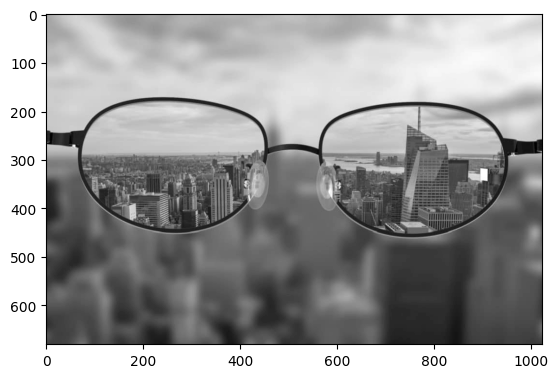

In [18]:
plt.imshow(image_gray, cmap='gray')

# 1. 데이터 생성 및 전처리

In [111]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [52]:
# print()
# for row in X_train[0]:
#     for pixel in row:
#         print('{:3.0f}'.format(pixel), end='')
#     print()

In [53]:
# plt.imshow(X_train[0], cmap='gray')

In [112]:
# 학습셋(6만개) -> 검증셋(1만개)+훈련셋(5만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [92]:
# 학습셋(5만개: fit용), 검증셋(1만:fit용), 테스트셋(1만, 평가용)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(50000, 28, 28) (50000,)
(10000, 28, 28) (10000,)
(10000, 28, 28) (10000,)


In [50]:
# 입력(독립) 변수 (n, 28,28) -> n, 784 -> 실수형변환 -> 스케일조정(255.0으로 나눠서)
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [51]:
# 훈련셋5만개, -> 8000개, 테스트셋 1만개 -> 2000개 추출 (목적: 학습시간 절약)
train_idx = np.random.choice(50000, 8000)
val_idx = np.random.choice(10000, 2000)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X = val_X[val_idx]
y_val = y_val[val_idx]

train_X.shape, y_train.shape, val_X.shape, y_val.shape, test_X.shape, y_test.shape

((8000, 784), (8000,), (2000, 784), (2000,), (10000, 784), (10000,))

In [57]:
# 타겟(종속)변수의 원핫코딩
train_Y = to_categorical(y_train, 10)
val_Y = to_categorical(y_val, 10)
test_Y = to_categorical(y_test, 10)
print(y_train[:2])
print(train_Y[:2])

train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

[1 2]
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]


((8000, 784), (8000, 10), (2000, 784), (2000, 10), (10000, 784), (10000, 10))

# 2. 모델 구성하기

In [61]:
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=196, activation='relu'))
model.add(Dense(units=49, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_13 (Dense)            (None, 196)               153860    
                                                                 
 dense_14 (Dense)            (None, 49)                9653      
                                                                 
 dense_15 (Dense)            (None, 10)                500       
                                                                 
Total params: 164,013
Trainable params: 164,013
Non-trainable params: 0
_________________________________________________________________


# 3. 학습과정 설정 & 4. 모델 학습

In [62]:
%%time
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
model.compile(loss='categorical_crossentropy', # sparce_categorical_crossentropy
             optimizer=Adam(learning_rate=0.01),
             metrics=['accuracy', # 정확도
                      metrics.Recall(), # 재현율(실제값 중심)
                      metrics.Precision()]) # 정밀도(예측값 중심)

hist = model.fit(train_X, train_Y, # 훈련데이터
                epochs=50, # 학습횟수
                batch_size=4000, # 한번에 읽어들이는 데이터 양
                validation_data=(val_X, val_Y), # 검증 데이터
#                 validation_split=0.2, # 검증데이터를 훈련데이터의 20%로 사용
                verbose=1 # 학습 로그 출력 여부 (0: 출력x, 1:출력o(default), 2:출력자세히o)
                )

Epoch 1/50
2/2 [==============================] - 2s 352ms/step - loss: 2.1706 - accuracy: 0.1458 - recall: 0.0264 - precision: 0.4817 - val_loss: 1.4065 - val_accuracy: 0.5690 - val_recall: 0.1460 - val_precision: 0.9605
Epoch 2/50
2/2 [==============================] - 0s 61ms/step - loss: 1.3362 - accuracy: 0.5639 - recall: 0.2756 - precision: 0.8068 - val_loss: 0.9298 - val_accuracy: 0.7075 - val_recall: 0.5915 - val_precision: 0.8591
Epoch 3/50
2/2 [==============================] - 0s 67ms/step - loss: 0.8250 - accuracy: 0.7294 - recall: 0.6112 - precision: 0.8485 - val_loss: 0.6401 - val_accuracy: 0.8010 - val_recall: 0.7185 - val_precision: 0.8762
Epoch 4/50
2/2 [==============================] - 0s 63ms/step - loss: 0.6181 - accuracy: 0.8071 - recall: 0.7326 - precision: 0.8717 - val_loss: 0.4995 - val_accuracy: 0.8445 - val_recall: 0.8180 - val_precision: 0.8872
Epoch 5/50
2/2 [==============================] - 0s 66ms/step - loss: 0.4822 - accuracy: 0.8494 - recall: 0.8165 -

Epoch 38/50
2/2 [==============================] - 0s 61ms/step - loss: 0.0132 - accuracy: 0.9984 - recall: 0.9976 - precision: 0.9986 - val_loss: 0.2008 - val_accuracy: 0.9525 - val_recall: 0.9505 - val_precision: 0.9567
Epoch 39/50
2/2 [==============================] - 0s 63ms/step - loss: 0.0119 - accuracy: 0.9986 - recall: 0.9980 - precision: 0.9989 - val_loss: 0.2043 - val_accuracy: 0.9515 - val_recall: 0.9505 - val_precision: 0.9567
Epoch 40/50
2/2 [==============================] - 0s 57ms/step - loss: 0.0108 - accuracy: 0.9992 - recall: 0.9991 - precision: 0.9992 - val_loss: 0.2089 - val_accuracy: 0.9515 - val_recall: 0.9500 - val_precision: 0.9557
Epoch 41/50
2/2 [==============================] - 0s 67ms/step - loss: 0.0098 - accuracy: 0.9995 - recall: 0.9992 - precision: 0.9995 - val_loss: 0.2095 - val_accuracy: 0.9515 - val_recall: 0.9500 - val_precision: 0.9557
Epoch 42/50
2/2 [==============================] - 0s 61ms/step - loss: 0.0089 - accuracy: 0.9994 - recall: 0.99

# 5. 모델 평가하기

In [63]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall', 'precision', 'val_loss', 'val_accuracy', 'val_recall', 'val_precision'])

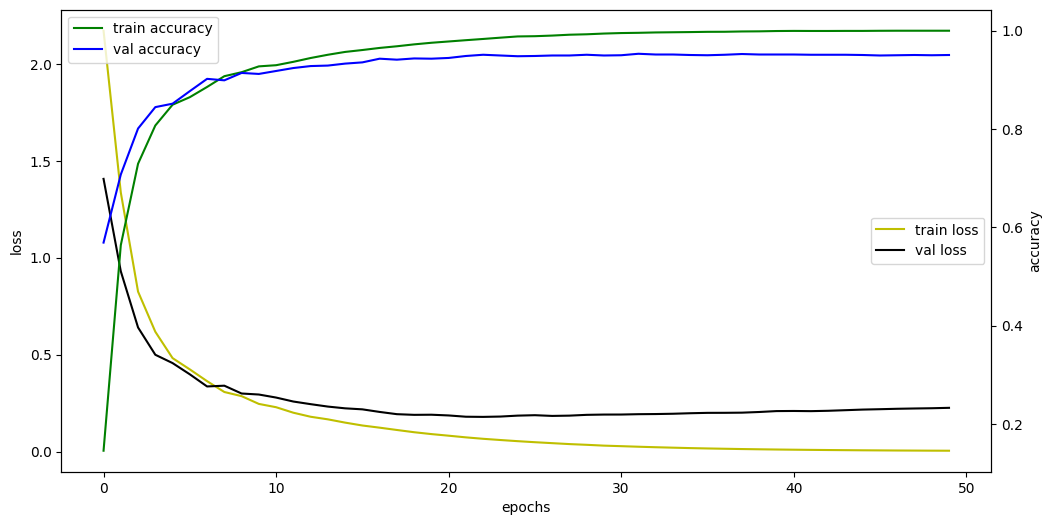

In [64]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'k', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
# acc_ax.plot(hist.history['recall'], 'g', label='train recall')
# acc_ax.plot(hist.history['precision'], 'g', label='train precision')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
# acc_ax.plot(hist.history['val_recall'], 'b', label='val recall')
# acc_ax.plot(hist.history['val_precision'], 'b', label='val precision')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [70]:
# 모델 평가하기
loss_and_mertics = model.evaluate(test_X, test_Y, batch_size=1000, verbose=1)
# print('loss :', loss_and_mertics[0])
# print('accuracy :', loss_and_mertics[1])
# print('recall :', loss_and_mertics[1])
# print('precision :', loss_and_mertics[1])
# 교차표
y_hat = model.predict(test_X).argmax(axis=1)
y_hat
# pd.crosstab(test_y.reshape(-1), y_hat,
#            rownames=['실제값'],
#            colnames=['예측값'])

313/313 [==============================] - 1s 2ms/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

# ※ 위 모델(DNN)의 accuracy늘리기
- 데이터 확보
- 모델 수정(레이어 추가, units수 증가)
- 과적합 방지(validation data추가, dropout, 활성화함수 relu계열, tanh)
- epoch 조정
- optimizer 변경

In [113]:
# 입력(독립) 변수 (n, 28,28) -> n, 784 -> 실수형변환 -> 스케일조정(255.0으로 나눠서)
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
print(train_X.shape, val_X.shape, test_X.shape)

(50000, 784) (10000, 784) (10000, 784)


In [114]:
# 훈련셋5만개, -> 40000개, 테스트셋 1만개 -> 9000개 추출 (목적: 학습시간 고려하되 모든 데이터 이용)
train_idx = np.random.choice(50000, 50000)
val_idx = np.random.choice(10000, 10000)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X = val_X[val_idx]
y_val = y_val[val_idx]
print(train_X.shape, y_train.shape, val_X.shape, y_val.shape, test_X.shape, y_test.shape)

(50000, 784) (50000,) (10000, 784) (10000,) (10000, 784) (10000,)


In [137]:
%%time

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=392, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=196, activation='tanh'))
model.add(Dropout(0.2))
model.add(Dense(units=98, activation='tanh'))
model.add(Dropout(0.2))
model.add(Dense(units=49, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_36 (Dense)            (None, 392)               307720    
                                                                 
 dropout (Dropout)           (None, 392)               0         
                                                                 
 dense_37 (Dense)            (None, 196)               77028     
                                                                 
 dropout_1 (Dropout)         (None, 196)               0         
                                                                 
 dense_38 (Dense)            (None, 98)                19306     
                                                                 
 dropout_2 (Dropout)         (None, 98)                0         
                                                                 
 dense_39 (Dense)            (None, 49)               

In [128]:
# 타겟(종속)변수의 원핫코딩
train_Y = to_categorical(y_train, 10)
val_Y = to_categorical(y_val, 10)
test_Y = to_categorical(y_test, 10)
print(y_train[:2])
print(train_Y[:2])

train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

[4 8]
[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]


((50000, 784),
 (50000, 10),
 (10000, 784),
 (10000, 10),
 (10000, 784),
 (10000, 10))

In [129]:
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
model.compile(loss='categorical_crossentropy', # sparce_categorical_crossentropy
             optimizer=Adam(learning_rate=0.01),
             metrics=['accuracy', # 정확도
                      metrics.Recall(), # 재현율(실제값 중심)
                      metrics.Precision()]) # 정밀도(예측값 중심)

hist = model.fit(train_X, train_Y, # 훈련데이터
                epochs=30, # 학습횟수
                batch_size=10000, # 한번에 읽어들이는 데이터 양
                validation_data=(val_X, val_Y), # 검증 데이터
#                 validation_split=0.2, # 검증데이터를 훈련데이터의 20%로 사용
                verbose=1 # 학습 로그 출력 여부 (0: 출력x, 1:출력o(default), 2:출력자세히o)
                )

Epoch 1/30
5/5 [==============================] - 2s 227ms/step - loss: 2.0280 - accuracy: 0.3994 - recall_9: 0.2234 - precision_9: 0.5060 - val_loss: 1.1865 - val_accuracy: 0.5958 - val_recall_9: 0.4650 - val_precision_9: 0.7907
Epoch 2/30
5/5 [==============================] - 1s 125ms/step - loss: 0.9138 - accuracy: 0.6946 - recall_9: 0.5634 - precision_9: 0.8411 - val_loss: 0.5719 - val_accuracy: 0.8188 - val_recall_9: 0.7699 - val_precision_9: 0.8694
Epoch 3/30
5/5 [==============================] - 1s 125ms/step - loss: 0.5256 - accuracy: 0.8410 - recall_9: 0.8036 - precision_9: 0.8847 - val_loss: 0.3583 - val_accuracy: 0.8948 - val_recall_9: 0.8734 - val_precision_9: 0.9208
Epoch 4/30
5/5 [==============================] - 1s 126ms/step - loss: 0.3579 - accuracy: 0.8951 - recall_9: 0.8763 - precision_9: 0.9195 - val_loss: 0.2621 - val_accuracy: 0.9198 - val_recall_9: 0.9029 - val_precision_9: 0.9371
Epoch 5/30
5/5 [==============================] - 1s 124ms/step - loss: 0.2613 -

In [130]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall_9', 'precision_9', 'val_loss', 'val_accuracy', 'val_recall_9', 'val_precision_9'])

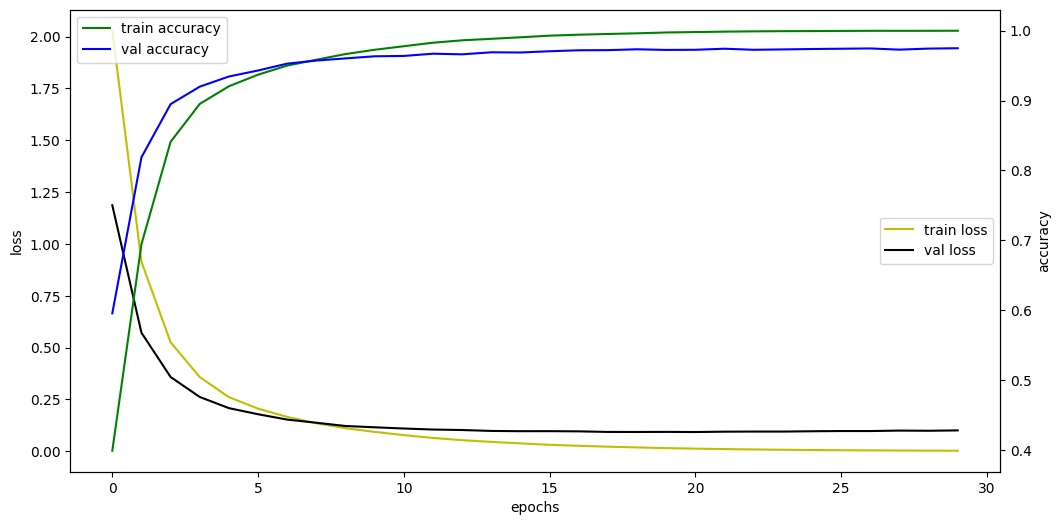

In [131]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'k', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
# acc_ax.plot(hist.history['recall_3'], 'g', label='train recall')
# acc_ax.plot(hist.history['precision_3'], 'g', label='train precision')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
# acc_ax.plot(hist.history['val_recall_3'], 'b', label='val recall')
# acc_ax.plot(hist.history['val_precision_3'], 'b', label='val precision')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [132]:
# 모델 평가하기
loss_and_mertics = model.evaluate(test_X, test_Y, batch_size=1000, verbose=1)

# 교차표
y_hat = model.predict(test_X).argmax(axis=1)
print(y_hat)
pd.crosstab(y_test.reshape(-1), y_hat,
           rownames=['실제값'],
           colnames=['예측값'])

313/313 [==============================] - 1s 3ms/step
[7 2 1 ... 4 5 6]


예측값,0,1,2,3,4,5,6,7,8,9
실제값,,,,,,,,,,
0,963,0,0,2,1,3,6,2,1,2
1,0,1123,4,2,0,1,3,0,2,0
2,5,1,993,10,2,1,3,8,9,0
3,0,0,7,985,0,2,0,5,6,5
4,1,0,0,1,949,1,3,2,3,22
5,4,0,1,18,1,849,8,0,6,5
6,7,2,2,1,4,5,935,0,2,0
7,0,3,8,2,3,1,0,1002,2,7
8,4,1,3,8,3,4,2,2,944,3


In [133]:
10000-10000*loss_and_mertics[1]

285.9997749328613

In [134]:
cnt = 0
for y,h in zip(y_test, y_hat):
    if y!=h:
        cnt+=1
print('틀린갯수 :', cnt)

틀린갯수 : 286


In [135]:
# 모델 저장
model.save('model/08_mnist.h5')

In [136]:
loss_and_mertics

[0.11855943500995636,
 0.9714000225067139,
 0.9708999991416931,
 0.9729431867599487]

# ※ 콜백함수1 : 로그 출력

In [138]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

In [140]:
%%time
# 매번 로그 출력하면 지저분해 질 수 있으니, 특정 에포크마다 로그 출력하도록 제한
class CustomHistory(Callback):
    def __init__(self): # 생성자함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}): # 1epoch마다 자동 실행되는 함수
        self.epoch +1  # epoch맏 self.epoch값을 1씩 증가
        if self.epoch%10 == 0:
            print('epoch:{}, loss:{}, acc:{}, val_loss:{}, val_acc:{},'.\
                  format(self.epoch, 
                        logs.get('loss'),
                        logs.get('accuracy', '-'),
                        logs.get('val_loss', '-'),
                        logs.get('val_accuracy', '-')
                        )
                 )
            

(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0

train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=397, activation='relu')) # tanh, relu, elu, gelu
model.add(Dropout(0.3))
model.add(Dense(units=512, activation='elu'))
model.add(Dropout(0.3))
model.add(Dense(units=128)) #  activation='leakyrelu'사용불가
from tensorflow.keras.layers import LeakyReLU
model.add(LeakyReLU(alpha=0.01)) 
model.add(Dropout(0.3))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='nadam',
             metrics=['accuracy'])
# 학습
customHistory = CustomHistory()
hist = model.fit(train_X, train_Y,
                epochs=50,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[customHistory]) # 콜백함수

Epoch 1/50
500/500 [==============================] - 7s 13ms/step - loss: 0.3235 - accuracy: 0.9009 - val_loss: 0.1185 - val_accuracy: 0.9646
Epoch 2/50
500/500 [==============================] - 6s 13ms/step - loss: 0.1487 - accuracy: 0.9549 - val_loss: 0.0923 - val_accuracy: 0.9711
Epoch 3/50
500/500 [==============================] - 6s 13ms/step - loss: 0.1116 - accuracy: 0.9659 - val_loss: 0.0896 - val_accuracy: 0.9742
Epoch 4/50
500/500 [==============================] - 6s 13ms/step - loss: 0.0928 - accuracy: 0.9717 - val_loss: 0.0930 - val_accuracy: 0.9741
Epoch 5/50
500/500 [==============================] - 6s 13ms/step - loss: 0.0814 - accuracy: 0.9745 - val_loss: 0.0843 - val_accuracy: 0.9781
Epoch 6/50
500/500 [==============================] - 7s 13ms/step - loss: 0.0741 - accuracy: 0.9773 - val_loss: 0.0798 - val_accuracy: 0.9777
Epoch 7/50
500/500 [==============================] - 7s 13ms/step - loss: 0.0657 - accuracy: 0.9799 - val_loss: 0.0823 - val_accuracy: 0.9781

Epoch 25/50
500/500 [==============================] - 7s 13ms/step - loss: 0.0306 - accuracy: 0.9907 - val_loss: 0.0887 - val_accuracy: 0.9822
Epoch 26/50
500/500 [==============================] - 7s 14ms/step - loss: 0.0308 - accuracy: 0.9908 - val_loss: 0.0919 - val_accuracy: 0.9813
Epoch 27/50
500/500 [==============================] - 7s 15ms/step - loss: 0.0286 - accuracy: 0.9914 - val_loss: 0.0974 - val_accuracy: 0.9812
Epoch 28/50
500/500 [==============================] - 7s 14ms/step - loss: 0.0289 - accuracy: 0.9908 - val_loss: 0.0972 - val_accuracy: 0.9815
Epoch 29/50
500/500 [==============================] - 7s 14ms/step - loss: 0.0304 - accuracy: 0.9908 - val_loss: 0.1027 - val_accuracy: 0.9800
Epoch 30/50
500/500 [==============================] - 7s 13ms/step - loss: 0.0293 - accuracy: 0.9911 - val_loss: 0.0995 - val_accuracy: 0.9808
Epoch 31/50
500/500 [==============================] - 7s 14ms/step - loss: 0.0305 - accuracy: 0.9908 - val_loss: 0.0972 - val_accuracy:

Epoch 49/50
500/500 [==============================] - 7s 13ms/step - loss: 0.0226 - accuracy: 0.9935 - val_loss: 0.1217 - val_accuracy: 0.9821
Epoch 50/50
500/500 [==============================] - 7s 13ms/step - loss: 0.0204 - accuracy: 0.9945 - val_loss: 0.1266 - val_accuracy: 0.9815
CPU times: total: 28min 52s
Wall time: 5min 38s


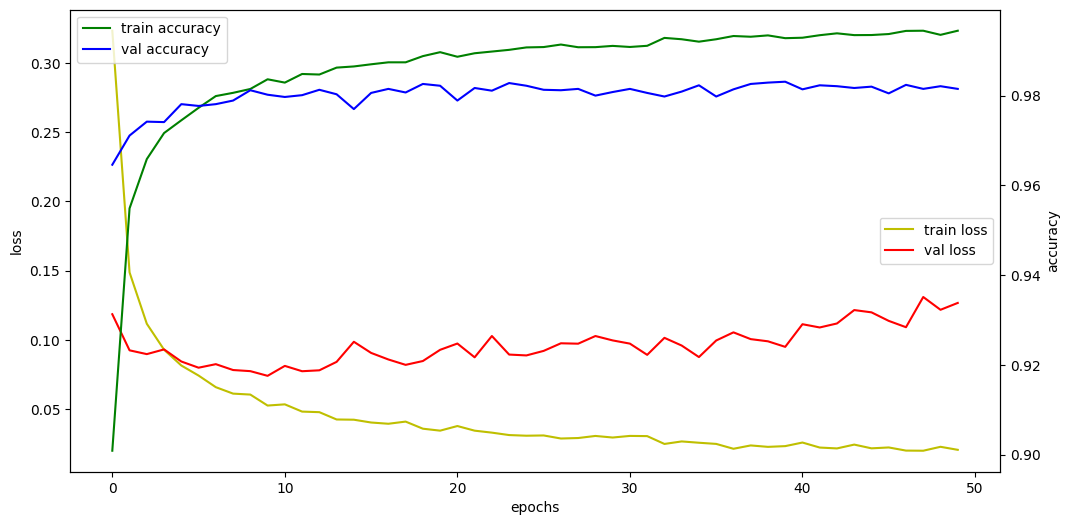

In [141]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

# ※ 콜백함수2: EarlyStopping
- val_loss값이 늘어나면 지정한 epoch를 다 수행하지 않고 조기 종료
- val_accuracy값이 감소하면 지정한 epoch를 다 수행하지 않고 조기 종료

In [147]:
%%time
# 매번 로그 출력하면 지저분해 질 수 있으니, 특정 에포크마다 로그 출력하도록 제한
class CustomHistory(Callback):
    def __init__(self): # 생성자함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}): # 1epoch마다 자동 실행되는 함수
        self.epoch +1  # epoch맏 self.epoch값을 1씩 증가
        if self.epoch%10 == 0:
            print('epoch:{}, loss:{}, acc:{}, val_loss:{}, val_acc:{},'.\
                  format(self.epoch, 
                        logs.get('loss'),
                        logs.get('accuracy', '-'),
                        logs.get('val_loss', '-'),
                        logs.get('val_accuracy', '-')
                        )
                 )
            
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0

train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=198, activation='relu')) # tanh, relu, elu, gelu
model.add(Dropout(0.3))
model.add(Dense(units=512, activation='elu'))
model.add(Dropout(0.3))
model.add(Dense(units=128)) #  activation='leakyrelu'사용불가
from tensorflow.keras.layers import LeakyReLU
model.add(LeakyReLU(alpha=0.01)) 
model.add(Dropout(0.3))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='nadam',
             metrics=['accuracy'])
# 학습
customHistory = CustomHistory()
earlystopping = EarlyStopping(monitor='val_accuracy', patience=3)
hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[customHistory, earlystopping]) # 콜백함수

Epoch 1/500
500/500 [==============================] - 6s 8ms/step - loss: 0.3648 - accuracy: 0.8892 - val_loss: 0.1288 - val_accuracy: 0.9630
Epoch 2/500
500/500 [==============================] - 4s 8ms/step - loss: 0.1694 - accuracy: 0.9496 - val_loss: 0.1051 - val_accuracy: 0.9686
Epoch 3/500
500/500 [==============================] - 4s 8ms/step - loss: 0.1345 - accuracy: 0.9585 - val_loss: 0.0899 - val_accuracy: 0.9727
Epoch 4/500
500/500 [==============================] - 4s 8ms/step - loss: 0.1129 - accuracy: 0.9655 - val_loss: 0.0849 - val_accuracy: 0.9750
Epoch 5/500
500/500 [==============================] - 4s 8ms/step - loss: 0.1046 - accuracy: 0.9682 - val_loss: 0.0883 - val_accuracy: 0.9748
Epoch 6/500
500/500 [==============================] - 4s 8ms/step - loss: 0.0890 - accuracy: 0.9722 - val_loss: 0.0833 - val_accuracy: 0.9770
Epoch 7/500
500/500 [==============================] - 4s 8ms/step - loss: 0.0830 - accuracy: 0.9740 - val_loss: 0.0792 - val_accuracy: 0.9774

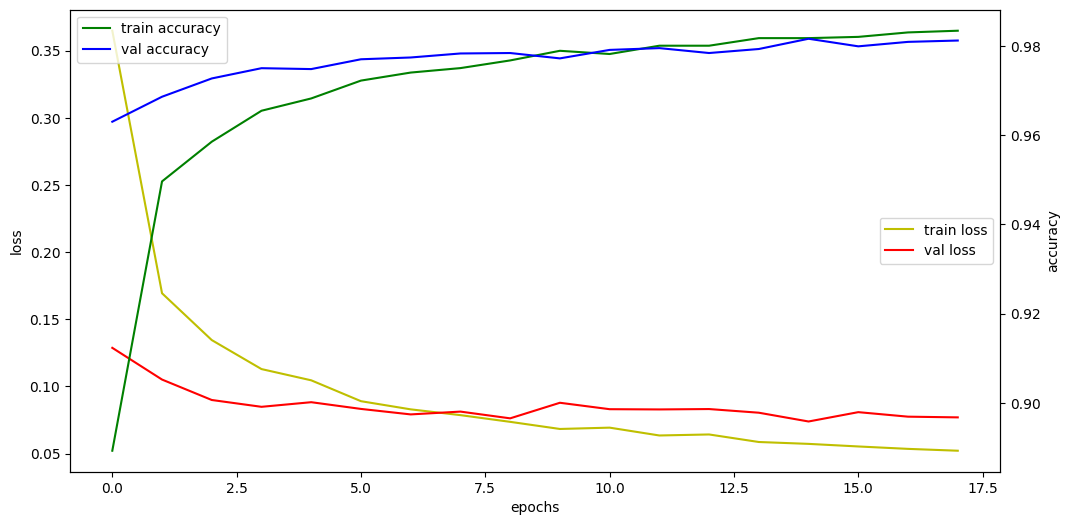

In [148]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

# ※ 콜백함수3: ModelCheckPoint
- epoch마다 val_accuracy(val_loss, accuracy, loss)값이 좋을 때, 모델을 자동 저장하는 콜백

In [154]:
%%time
# 매번 로그 출력하면 지저분해 질 수 있으니, 특정 에포크마다 로그 출력하도록 제한
class CustomHistory(Callback):
    def __init__(self): # 생성자함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}): # 1epoch마다 자동 실행되는 함수
        self.epoch +1  # epoch맏 self.epoch값을 1씩 증가
        if self.epoch%10 == 0:
            print('epoch:{}, loss:{}, acc:{}, val_loss:{}, val_acc:{},'.\
                  format(self.epoch, 
                        logs.get('loss'),
                        logs.get('accuracy', '-'),
                        logs.get('val_loss', '-'),
                        logs.get('val_accuracy', '-')
                        )
                 )
            
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0

train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=198, activation='relu')) # tanh, relu, elu, gelu
model.add(Dropout(0.3))
model.add(Dense(units=512, activation='elu'))
model.add(Dropout(0.3))
model.add(Dense(units=128)) #  activation='leakyrelu'사용불가
from tensorflow.keras.layers import LeakyReLU
model.add(LeakyReLU(alpha=0.01)) 
model.add(Dropout(0.3))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='nadam',
             metrics=['accuracy'])
# 학습
customHistory = CustomHistory()
# monitor기준으로 patience번 이상 안 좋은 데이터가 나오면 조기 종료
earlystopping = EarlyStopping(monitor='val_accuracy', patience=3)

# 모델 자동 저장 콜백
import os
model_save_folder = './model08/'
if not os.path.exists(model_save_folder): # 폴더가 없으면 폴던 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'mnist-{epoch:03d}-val{val_accuracy:.4f}.h5'
checkpoint = ModelCheckpoint(filepath=file,
                        monitor='val_accuracy', # 모니터할 지표
                        save_best_only=True, # 모니터링 지표가 개선된 경우만 저장
                        mode='max', # 값이 클수록 저장
                        verbose=1 # 저장시 로그 출력
                      )
hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[customHistory, earlystopping, checkpoint]) # 콜백함수

Epoch 1/500
498/500 [============================>.] - ETA: 0s - loss: 0.3655 - accuracy: 0.8877epoch:0, loss:0.36499664187431335, acc:0.8878600001335144, val_loss:0.12329160422086716, val_acc:0.9624999761581421,

Epoch 1: val_accuracy improved from -inf to 0.96250, saving model to ./model08\mnist-001-val0.9625.h5
500/500 [==============================] - 5s 7ms/step - loss: 0.3650 - accuracy: 0.8879 - val_loss: 0.1233 - val_accuracy: 0.9625
Epoch 2/500
492/500 [============================>.] - ETA: 0s - loss: 0.1747 - accuracy: 0.9481epoch:0, loss:0.17397798597812653, acc:0.948360025882721, val_loss:0.09970776736736298, val_acc:0.9690999984741211,

Epoch 2: val_accuracy improved from 0.96250 to 0.96910, saving model to ./model08\mnist-002-val0.9691.h5
500/500 [==============================] - 4s 8ms/step - loss: 0.1740 - accuracy: 0.9484 - val_loss: 0.0997 - val_accuracy: 0.9691
Epoch 3/500
497/500 [============================>.] - ETA: 0s - loss: 0.1369 - accuracy: 0.9583epoch:0,